### load packages

In [1]:
import json
from atproto import Client, models
import requests
import pandas as pd

import spacy
from collections import Counter

import re
import plotly.express as px

### API and data prepare

In [4]:
# The public AppView API allows us to fetch data for public accounts without logging in
BASE_URL = "https://public.api.bsky.app/xrpc/"

In [17]:
# 1. Your specific account handle
my_account = "jieyideng.bsky.social" 

# 2. Endpoint to fetch the list of users you follow
follows_endpoint = f"{BASE_URL}app.bsky.graph.getFollows"

In [6]:
# Fetch your following list (limiting to 10 for a lightweight start)
response = requests.get(follows_endpoint, params={"actor": my_account, "limit": 10})
follows_data = response.json()

# Extract the handles of people you follow
following_handles = [user["handle"] for user in follows_data.get("follows", [])]
print(f"You follow {len(following_handles)} users. Analyzing posts for: {following_handles}")

all_posts = []
posts_endpoint = f"{BASE_URL}app.bsky.feed.getAuthorFeed"

for handle in following_handles:
    try:
        # Get the latest 5 posts for each person you follow
        feed_response = requests.get(posts_endpoint, params={"actor": handle, "limit": 5})
        feed_items = feed_response.json().get("feed", [])
        
        for item in feed_items:
            post = item.get("post", {})
            record = post.get("record", {})
            all_posts.append({
                "Following": handle,
                "Text": record.get("text", ""),
                "Created At": record.get("createdAt", ""),
                "Likes": post.get("likeCount", 0),
                "Reposts": post.get("repostCount", 0)
            })
    except Exception as e:
        print(f"Could not fetch posts for {handle}: {e}")

# Build the structured DataFrame
df_following = pd.DataFrame(all_posts)
df_following["Created At"] = pd.to_datetime(df_following["Created At"])
df_following = df_following.sort_values(by="Created At", ascending=False)

print("\n--- Extraction Complete ---")
display(df_following.head(10))

You follow 10 users. Analyzing posts for: ['steipete.me', 'bluecrawler.com', 'brittanyellich.com', 'ashley.dev', 'cassidoo.co', 'addyosmani.bsky.social', 'simonwillison.net', 'martin.kleppmann.com', 'gergely.pragmaticengineer.com', 'b0rk.jvns.ca']

--- Extraction Complete ---


,Following,Text,Created At,Likes,Reposts
10,brittanyellich.com,"Hey look, it's my face on the @github.com blog...",2026-04-15 18:21:09.501000+00:00,7,1
30,simonwillison.net,"Hah, you have to embrace biased cliches in you...",2026-04-15 17:29:09.232000+00:00,6,0
31,simonwillison.net,I ran the same prompt for a London Estuary acc...,2026-04-15 17:28:28.791000+00:00,11,0
32,simonwillison.net,The example prompt for Google's new Gemini Fla...,2026-04-15 17:16:36.177000+00:00,36,5
40,gergely.pragmaticengineer.com,BUT the handler is disabled when the text has ...,2026-04-15 14:28:01.147000+00:00,7,0
11,brittanyellich.com,This is very soothing 😌,2026-04-15 13:56:52.838000+00:00,2,0
12,brittanyellich.com,Idk when I think of the official soundtrack of...,2026-04-15 13:52:03.908000+00:00,4,0
13,brittanyellich.com,I have one of those. He's not green but he is ...,2026-04-15 13:48:00.428000+00:00,2,0
41,gergely.pragmaticengineer.com,I'm sure there's a team at Notion patting thei...,2026-04-15 13:44:47.988000+00:00,74,4
42,gergely.pragmaticengineer.com,I hate AI when it's like this:\n\nNotion used ...,2026-04-15 13:44:09.938000+00:00,114,11


### analysis and visualization:
Here, I would like to know which tech company or new techs are mentioned in the posts 

In [14]:
# Define the dictionary of entities we want to track. 
# You can easily expand this to include specific industry players or tools you are analyzing.
tech_keywords = {
    "Companies": ["apple", "google", "microsoft", "amazon", "meta", "openai", "anthropic", "claude", "codex", "gemini", "nvidia"],
    "Technologies": ["ai", "machine learning", "data science", "llm", "python", "cloud", "generative ai", "api"]
}

# Flatten the dictionary into a single list for searching
all_keywords = tech_keywords["Companies"] + tech_keywords["Technologies"]

# Function to count keyword mentions in a given text
def count_mentions(text, keywords):
    if not isinstance(text, str):
        return {}
    
    text_lower = text.lower()
    mentions = {}
    
    for keyword in keywords:
        # Use regex to find whole word matches only (e.g., 'ai' but not 'said')
        pattern = r'\b' + re.escape(keyword) + r'\b'
        count = len(re.findall(pattern, text_lower))
        if count > 0:
            mentions[keyword] = count
            
    return mentions

# Apply the extraction function to the text column
df_following['Mentions'] = df_following['Text'].apply(lambda x: count_mentions(x, all_keywords))

# Create a master dictionary of total counts across the entire feed
total_mentions = {}
for mention_dict in df_following['Mentions']:
    for keyword, count in mention_dict.items():
        total_mentions[keyword] = total_mentions.get(keyword, 0) + count


In [15]:
# Convert the results into a new DataFrame for easy plotting
df_mentions = pd.DataFrame(list(total_mentions.items()), columns=['Entity', 'Mention Count'])
df_mentions = df_mentions.sort_values(by='Mention Count', ascending=False)

print("Analysis complete! Here are the raw counts:")
display(df_mentions.head(10))

Analysis complete! Here are the raw counts:


,Entity,Mention Count
0,ai,12
1,google,1
2,gemini,1
3,api,1
4,anthropic,1


### simple nlp

In [10]:
nlp = spacy.load("en_core_web_sm")

def extract_nouns(text):

    if not isinstance(text, str):
        return []
    
    doc = nlp(text)
    nouns = []
    for token in doc:

        if token.pos_ in ['NOUN', 'PROPN'] and not token.is_stop and token.is_alpha:
            nouns.append(token.lemma_.lower())
    return nouns

In [12]:
df_following['Extracted_Nouns'] = df_following['Text'].apply(extract_nouns)

all_nouns = [noun for sublist in df_following['Extracted_Nouns'] for noun in sublist]

noun_counts = Counter(all_nouns)
top_10_nouns = noun_counts.most_common(10)

df_top_nouns = pd.DataFrame(top_10_nouns, columns=['Noun', 'Frequency'])

display(df_top_nouns)

,Noun,Frequency
0,ai,10
1,blog,5
2,thank,5
3,text,5
4,work,5
5,proof,4
6,bit,4
7,dns,4
8,post,3
9,prompt,3


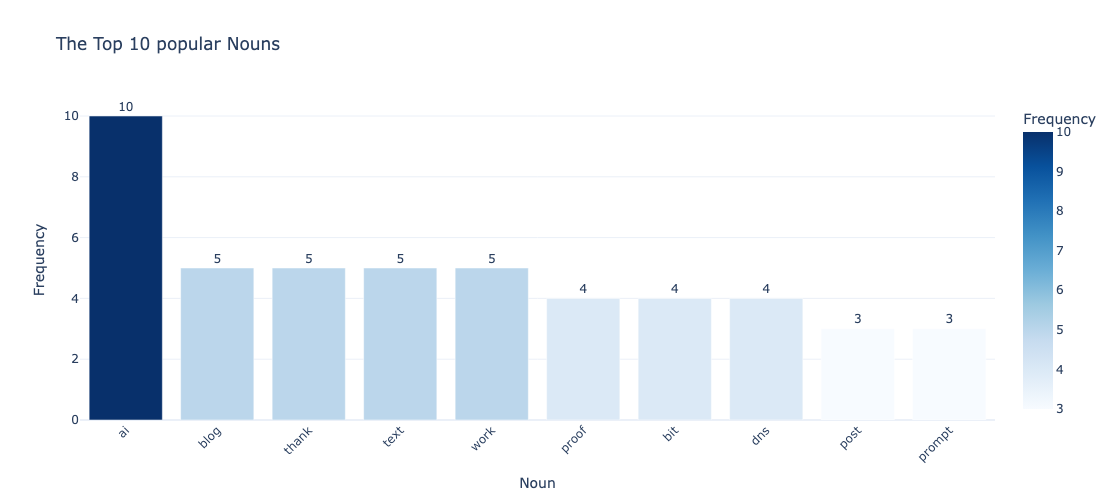

In [16]:
# plot the distribution of top 10 noun_counts

fig = px.bar(df_top_nouns, 
             x='Noun', 
             y='Frequency',
             title="The Top 10 popular Nouns",
             text='Frequency',
             color='Frequency',
             color_continuous_scale='Blues')
    
    # 优化图表排版
fig.update_traces(textposition='outside')
fig.update_layout(xaxis_tickangle=-45,
                  template='plotly_white',
                  height=500,
                  width=800)
fig.show()